# Evaluación en test del detector de partes (car_parts v2)

Evalúa un checkpoint de `car_parts` **con las mismas clases con las que se entrenó**. Si el
checkpoint trae `class_map` (v2), el ground truth se remapea con él: 29 clases finales.
Si no lo trae (v1), se usan las 47 clases originales. Con la versión anterior del notebook,
un checkpoint de v2 se comparaba contra las ids originales sin ningún error.

Qué calcula:
1. COCO AP de **cajas** y **máscaras** (pycocotools), global y por clase, con el número de
   instancias y la marca *poco fiable* (< 10 instancias en el split).
2. Visualización de predicciones (máscaras) contra el ground truth.
3. Salida de M2 para M3: un JSON por imagen `{clase_parte, confianza, bbox, máscara}` con
   la máscara de cada parte como PNG.

Para el **veredicto v1 contra v2** (mismas clases, bootstrap, IC 95 %) usar
`python -m src.detection.car_parts.compare_versions --split test`, no este notebook.

In [1]:
import contextlib
import copy
import io
import json
import os
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from pycocotools import mask as mask_utils
from pycocotools.cocoeval import COCOeval
from torch.utils.data import DataLoader

# Project root = first parent folder that contains src/. The configs use paths relative to it.
current = Path(os.getcwd()).resolve()
while current != current.parent and not (current / "src").exists():
    current = current.parent
PROJECT_ROOT = current
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from src.detection.car_parts.class_map import CLASS_MAP
from src.detection.car_parts.config import CONFIG, MASK_CONFIG
from src.detection.common.coco_dataset import build_dataset, collate_fn, polygons_to_mask
from src.detection.common.coco_eval import STAT_NAMES, collect_detections, load_coco_gt
from src.detection.common.model import build_model

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos


## 1. Parámetros

`M2_CHECKPOINT`, `M2_SPLIT` y `M2_DEVICE` como variables de entorno permiten correr el
notebook sin editarlo (por ejemplo, con el checkpoint de v1).

In [2]:
CHECKPOINT_PATH = Path(os.environ.get("M2_CHECKPOINT", "models/checkpoints/car_parts/v2/best_model.pth"))
SPLIT = os.environ.get("M2_SPLIT", "test")
DEVICE = torch.device(os.environ.get("M2_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))

SCORE_THRESHOLD = 0.5    # only for the visualization and the M2 output; AP uses every score
UNRELIABLE_BELOW = 10    # classes with fewer instances in the split are marked "poco fiable"
NUM_SAMPLES = 6          # images to visualize
# Masks are binarized at 0.5 inside collect_detections (coco_eval._encode_mask).
OUTPUT_DIR = Path("tests/detection/outputsM2") / CHECKPOINT_PATH.parent.name

print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Split: {SPLIT}  |  Device: {DEVICE}  |  Output M2: {OUTPUT_DIR}")
if SPLIT != "test":
    print("AVISO: 'valid' sirve para elegir el checkpoint; el resultado a reportar se calcula en 'test'.")

Checkpoint: models\checkpoints\car_parts\v2\best_model.pth
Split: test  |  Device: cuda  |  Output M2: tests\detection\outputsM2\v2


## 2. Cargar el checkpoint

In [3]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"No existe {CHECKPOINT_PATH}. ¿Ya terminó el entrenamiento?")

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
ARCH = ckpt.get("arch", "faster_rcnn")
WITH_MASKS = bool(ckpt.get("with_masks", False))
CKPT_CLASS_MAP = ckpt.get("class_map")
categories = {int(k): v for k, v in ckpt["categories"].items()}

model = build_model(ckpt["num_classes"], arch=ARCH, pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE).eval()

val_coco = ckpt.get("coco", {})
print(f"Arquitectura: {ARCH}  |  Máscaras: {WITH_MASKS}  |  Clases: {len(categories)} (+ fondo)")
print(f"class_map: {'sí' if CKPT_CLASS_MAP is not None else 'no (clases originales)'}")
print(f"Época guardada: {ckpt.get('epoch')}  |  elegido por: {ckpt.get('select_by', 'bbox')} AP")
print(f"Semilla: {ckpt.get('seed', '-')}  |  augmentation: {ckpt.get('augmented', '-')}  |  freeze_bn: {ckpt.get('freeze_bn', '-')}")
for iou_type in ("bbox", "segm"):
    if iou_type in val_coco:
        s = val_coco[iou_type]
        print(f"Val {iou_type}: AP {s['AP']:.4f}  AP50 {s['AP50']:.4f}")

Arquitectura: mask_rcnn  |  Máscaras: True  |  Clases: 29 (+ fondo)
class_map: sí
Época guardada: 16  |  elegido por: segm AP
Semilla: 42  |  augmentation: True  |  freeze_bn: False
Val bbox: AP 0.6664  AP50 0.8583
Val segm: AP 0.6435  AP50 0.8710


## 3. Cargar el split con las clases del checkpoint

El `assert` garantiza que las ids del ground truth significan lo mismo que las del modelo.

In [4]:
if CKPT_CLASS_MAP is not None and CKPT_CLASS_MAP != CLASS_MAP:
    raise ValueError("El checkpoint se entrenó con un class_map distinto al actual de "
                     "src/detection/car_parts/class_map.py; sus clases no coinciden.")

cfg = MASK_CONFIG if CKPT_CLASS_MAP is not None else CONFIG
dataset = build_dataset(cfg, SPLIT, use_class_map=CKPT_CLASS_MAP is not None)
assert dataset.categories == categories, "Las clases del dataset no coinciden con las del checkpoint"

img_ids = dataset.coco_image_ids
instances = Counter(a["category_id"] for a in dataset.coco_gt["annotations"]
                    if a["image_id"] in set(img_ids) and not a.get("iscrowd", 0))
print(f"Imágenes: {len(dataset)}  |  Instancias: {sum(instances.values())}  |  Clases: {len(categories)}")
if dataset.class_map_stats:
    st = dataset.class_map_stats
    print(f"Instancias descartadas por el class_map: {sum(st['instances_discarded'].values())} "
          f"{st['instances_discarded']}")
missing = [categories[c] for c in categories if instances[c] == 0]
print(f"Clases sin instancias en {SPLIT}: {missing or 'ninguna'}")

Imágenes: 16  |  Instancias: 396  |  Clases: 29
Instancias descartadas por el class_map: 23 {'air_intake': 1, 'back_light': 1, 'front_mirror': 6, 'windshield': 15}
Clases sin instancias en test: ninguna


## 4. Inferencia (una sola pasada; se reutiliza para métricas, figuras y salida de M2)

In [5]:
loader = DataLoader(dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
detections = collect_detections(model, loader, DEVICE, with_masks=WITH_MASKS)
print(f"Detecciones (todas las confianzas): {len(detections)}  |  "
      f">= {SCORE_THRESHOLD}: {sum(d['score'] >= SCORE_THRESHOLD for d in detections)}")

Evaluating:   0%|          | 0/8 [00:00<?, ?batch/s]

Evaluating:  12%|█▎        | 1/8 [00:01<00:08,  1.17s/batch]

Evaluating:  25%|██▌       | 2/8 [00:01<00:04,  1.30batch/s]

Evaluating:  38%|███▊      | 3/8 [00:02<00:03,  1.61batch/s]

Evaluating:  50%|█████     | 4/8 [00:02<00:02,  1.81batch/s]

...

Evaluating:  75%|███████▌  | 6/8 [00:03<00:01,  1.95batch/s]

Evaluating:  88%|████████▊ | 7/8 [00:03<00:00,  2.03batch/s]

Evaluating: 100%|██████████| 8/8 [00:04<00:00,  2.09batch/s]

Evaluating: 100%|██████████| 8/8 [00:04<00:00,  1.81batch/s]

Detecciones (todas las confianzas): 516  |  >= 0.5: 407


## 5. COCO AP en el split

AP@0.5:0.95 promediado solo sobre las clases del checkpoint (`params.catIds`) y las imágenes
del split. Las clases sin instancias quedan fuera del promedio, igual que en pycocotools.

In [6]:
coco_gt = load_coco_gt(dataset.coco_gt)
cat_ids = sorted(categories)


def coco_scores(iou_type):
    with contextlib.redirect_stdout(io.StringIO()):
        ev = COCOeval(coco_gt, coco_gt.loadRes(copy.deepcopy(detections)), iou_type)
        ev.params.catIds, ev.params.imgIds = cat_ids, img_ids
        ev.evaluate()
        ev.accumulate()
        ev.summarize()
    per_class = {}
    for k, cid in enumerate(ev.params.catIds):
        p = ev.eval["precision"][:, :, k, 0, -1]
        per_class[cid] = (float(p[p > -1].mean()), float(p[0][p[0] > -1].mean())) if (p > -1).any() else (None, None)
    return dict(zip(STAT_NAMES, map(float, ev.stats))), per_class


if not detections:
    raise RuntimeError("El modelo no produjo detecciones.")
IOU_TYPES = ["bbox"] + (["segm"] if WITH_MASKS else [])
scores = {t: coco_scores(t) for t in IOU_TYPES}

print(f"{'':6} {'AP':>7} {'AP50':>7} {'AP75':>7} {'APs':>7} {'APm':>7} {'APl':>7} {'AR100':>7}")
for t in IOU_TYPES:
    s = scores[t][0]
    label = "caja" if t == "bbox" else "máscara"
    print(f"{label:6} {s['AP']:7.4f} {s['AP50']:7.4f} {s['AP75']:7.4f} {s['AP_small']:7.4f} "
          f"{s['AP_medium']:7.4f} {s['AP_large']:7.4f} {s['AR_100']:7.4f}")

            AP    AP50    AP75     APs     APm     APl   AR100
caja    0.6041  0.8043  0.7021  0.3609  0.6494  0.6784  0.6982
máscara  0.5779  0.8047  0.6483  0.3336  0.6249  0.6558  0.6658


## 6. AP por clase

In [7]:
rows = []
for cid in cat_ids:
    row = {"clase": categories[cid], "instancias": instances[cid]}
    for t in IOU_TYPES:
        row[t] = scores[t][1][cid][0]
    rows.append(row)
rows.sort(key=lambda r: (r["bbox"] is None, -(r["bbox"] or 0)))

fmt = lambda v: "   -  " if v is None else f"{v:6.3f}"
header = f"{'clase':18} {'inst':>5} {'caja':>7}" + (f" {'máscara':>8}" if WITH_MASKS else "") + "  nota"
print(header)
print("-" * len(header))
for r in rows:
    note = "sin instancias" if r["instancias"] == 0 else ("poco fiable" if r["instancias"] < UNRELIABLE_BELOW else "")
    line = f"{r['clase']:18} {r['instancias']:5d} {fmt(r['bbox']):>7}"
    if WITH_MASKS:
        line += f" {fmt(r['segm']):>8}"
    print(line + f"  {note}")

clase               inst    caja  máscara  nota
-----------------------------------------------
back_glass             7   0.900    0.856  poco fiable
hood                   9   0.831    0.842  poco fiable
back_door_glass       16   0.825    0.825  
quarter_glass         10   0.808    0.732  
windshield            10   0.806    0.764  
bumper                10   0.745    0.740  
front_door_glass      15   0.744    0.717  
wheel                 30   0.738    0.746  
headlight             17   0.733    0.682  
tire                  41   0.712    0.792  
side_mirror           21   0.711    0.651  
radiator              16   0.692    0.700  
taillight             14   0.673    0.707  
fuel_cover            10   0.640    0.535  
front_door            16   0.634    0.665  
back_door             15   0.628    0.673  
emblem                 8   0.604    0.617  poco fiable
trunk                  7   0.603    0.466  poco fiable
handle                27   0.543    0.502  
front_fender          17

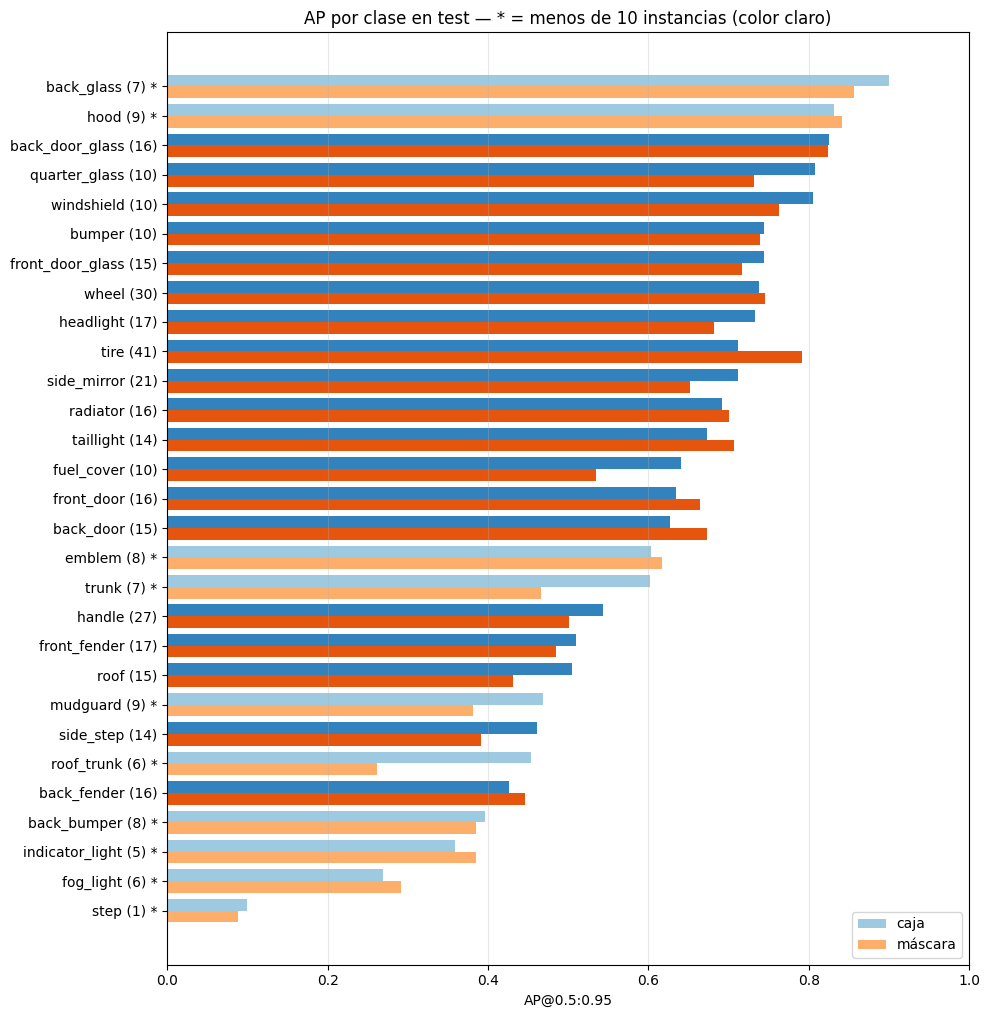

In [8]:
plot_rows = [r for r in rows if r["bbox"] is not None][::-1]
fig, ax = plt.subplots(figsize=(10, 0.32 * len(plot_rows) + 1))
y = np.arange(len(plot_rows))
h = 0.4 if WITH_MASKS else 0.8
unreliable = [r["instancias"] < UNRELIABLE_BELOW for r in plot_rows]
ax.barh(y + (h / 2 if WITH_MASKS else 0), [r["bbox"] for r in plot_rows], h, label="caja",
        color=["#9ecae1" if u else "#3182bd" for u in unreliable])
if WITH_MASKS:
    ax.barh(y - h / 2, [r["segm"] for r in plot_rows], h, label="máscara",
            color=["#fdae6b" if u else "#e6550d" for u in unreliable])
ax.set_yticks(y)
ax.set_yticklabels([f"{r['clase']} ({r['instancias']})" + (" *" if u else "") for r, u in zip(plot_rows, unreliable)])
ax.set_xlabel("AP@0.5:0.95")
ax.set_xlim(0, 1)
ax.set_title(f"AP por clase en {SPLIT} — * = menos de {UNRELIABLE_BELOW} instancias (color claro)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Predicciones contra ground truth

Las mismas `NUM_SAMPLES` imágenes en dos vistas: **7a máscaras** y **7b cajas**. Izquierda:
predicciones con confianza ≥ `SCORE_THRESHOLD`; derecha: ground truth con las clases del
checkpoint. Cada clase tiene el mismo color en todas las figuras.

In [9]:
rng = np.random.default_rng(0)
palette = {cid: tuple(int(c) for c in rng.integers(40, 255, 3)) for cid in cat_ids}
dets_by_image = {}
for d in detections:
    dets_by_image.setdefault(d["image_id"], []).append(d)


def put_label(img, text, org, color):
    x, y = int(org[0]), int(max(org[1], 12))
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, text, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)


def sample_items(image_id, anns, height, width):
    # (category_id, mask or None, xyxy box, label) for the predictions and the ground truth.
    preds = []
    for d in dets_by_image.get(image_id, []):
        if d["score"] < SCORE_THRESHOLD:
            continue
        x, y, w, h = d["bbox"]
        mask = mask_utils.decode(d["segmentation"]) if "segmentation" in d else None
        preds.append((d["category_id"], mask, (x, y, x + w, y + h),
                      f"{categories[d['category_id']]} {d['score']:.2f}"))
    gts = []
    for a in anns:
        x, y, w, h = a["bbox"]
        gts.append((a["category_id"], polygons_to_mask(a["segmentation"], height, width),
                    (x, y, x + w, y + h), categories[a["category_id"]]))
    return preds, gts


samples = []
for image_id, file_name, width, height, anns in dataset.samples[:min(NUM_SAMPLES, len(dataset))]:
    image = cv2.cvtColor(cv2.imread(os.path.join(dataset.images_dir, file_name)), cv2.COLOR_BGR2RGB)
    samples.append((file_name, image, *sample_items(image_id, anns, height, width)))
print(f"{len(samples)} imágenes para las secciones 7a y 7b")

6 imágenes para las secciones 7a y 7b


### 7a. Máscaras

Cada parte se rellena con el color de su clase y se contornea; la etiqueta va en el centro
de la máscara. Las partes grandes se dibujan primero para que las pequeñas queden encima.
Si el checkpoint no produce máscaras (v1), la columna de predicción queda vacía.

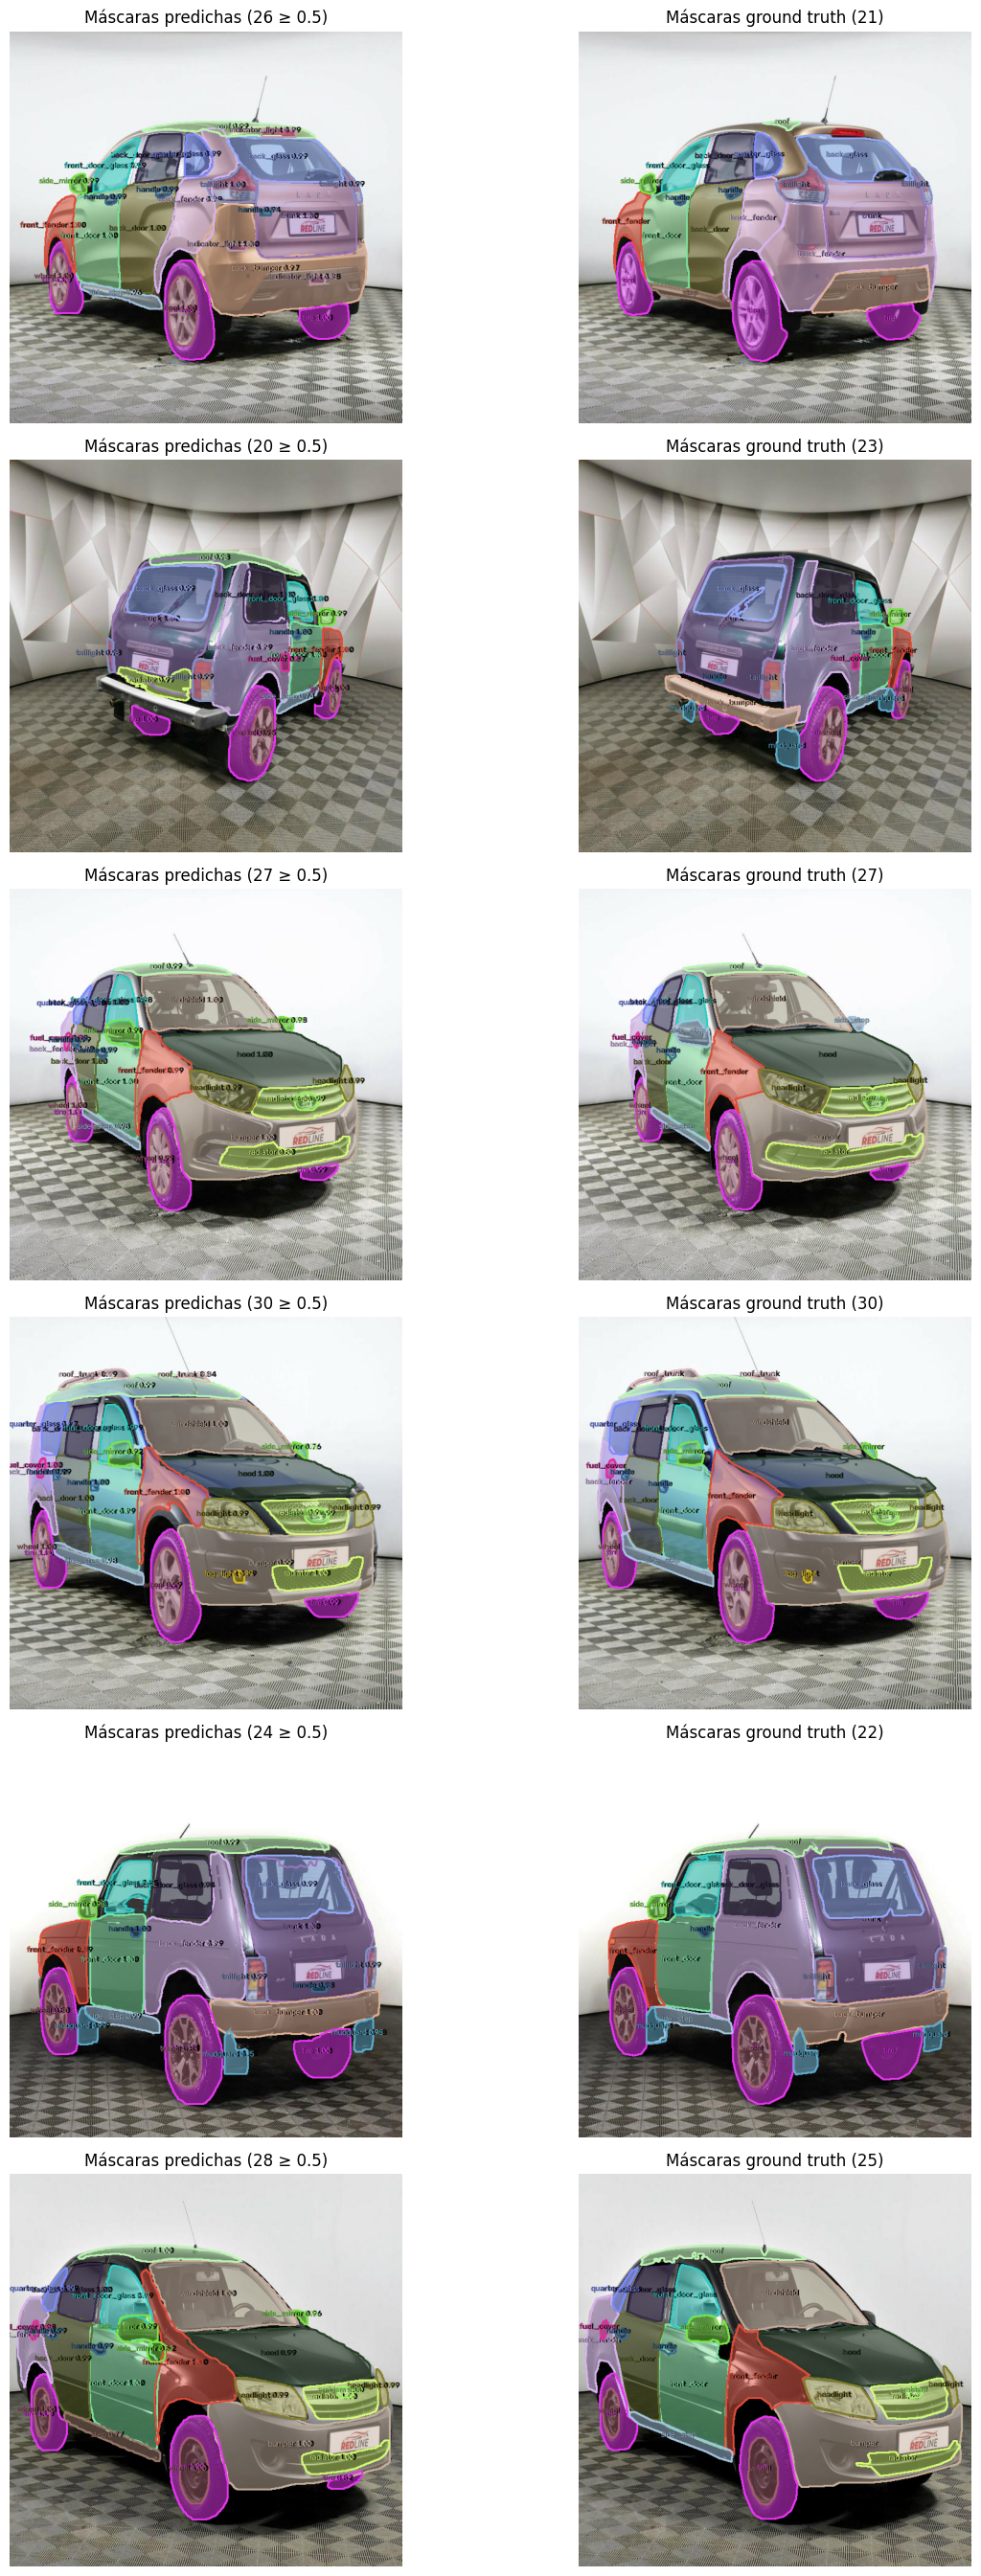

In [10]:
def draw_masks(image_rgb, items, alpha=0.5):
    items = [it for it in items if it[1] is not None]
    items.sort(key=lambda it: -int(it[1].sum()))
    overlay = image_rgb.copy()
    for cid, mask, _, _ in items:
        overlay[mask.astype(bool)] = palette[cid]
    out = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)
    for cid, mask, _, text in items:
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, palette[cid], 2)
        m = cv2.moments(mask.astype(np.uint8), binaryImage=True)
        if m["m00"] > 0:
            put_label(out, text, (m["m10"] / m["m00"] - 4 * len(text), m["m01"] / m["m00"]), palette[cid])
    return out, len(items)


fig, axes = plt.subplots(len(samples), 2, figsize=(14, 4.5 * len(samples)))
axes = np.atleast_2d(axes)
for row, (file_name, image, preds, gts) in enumerate(samples):
    pred_img, n_pred = draw_masks(image, preds)
    gt_img, n_gt = draw_masks(image, gts)
    axes[row, 0].imshow(pred_img)
    axes[row, 0].set_title(f"Máscaras predichas ({n_pred} ≥ {SCORE_THRESHOLD})" if WITH_MASKS
                           else "El checkpoint no produce máscaras")
    axes[row, 1].imshow(gt_img)
    axes[row, 1].set_title(f"Máscaras ground truth ({n_gt})")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

### 7b. Cajas

Solo las cajas `[x1, y1, x2, y2]` con la clase (y la confianza en las predicciones).

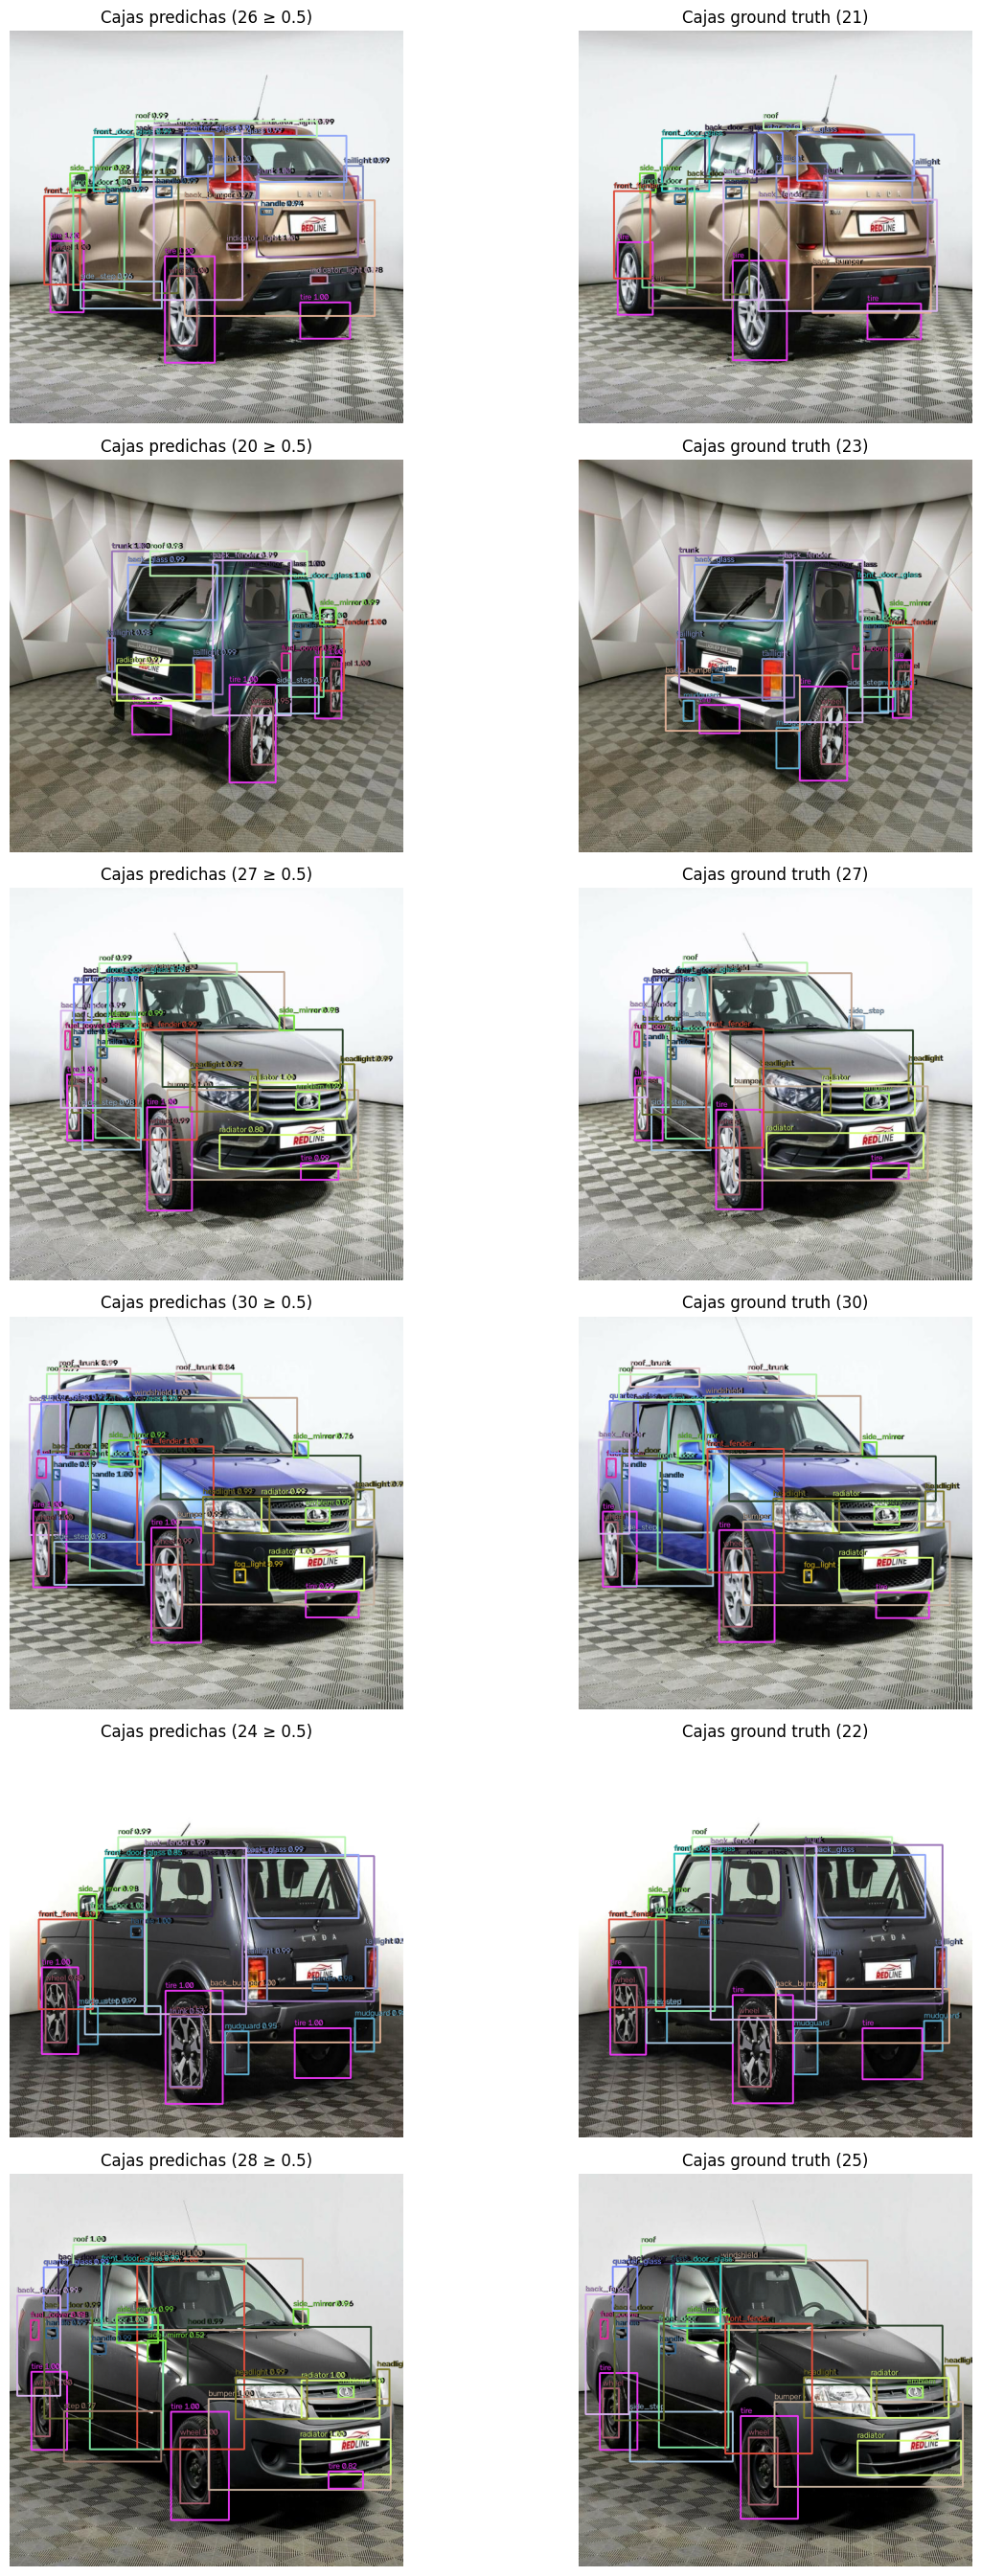

In [11]:
def draw_boxes(image_rgb, items):
    out = image_rgb.copy()
    for cid, _, box, text in items:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(out, (x1, y1), (x2, y2), palette[cid], 2)
        put_label(out, text, (x1, y1 - 4), palette[cid])
    return out


fig, axes = plt.subplots(len(samples), 2, figsize=(14, 4.5 * len(samples)))
axes = np.atleast_2d(axes)
for row, (file_name, image, preds, gts) in enumerate(samples):
    axes[row, 0].imshow(draw_boxes(image, preds))
    axes[row, 0].set_title(f"Cajas predichas ({len(preds)} ≥ {SCORE_THRESHOLD})")
    axes[row, 1].imshow(draw_boxes(image, gts))
    axes[row, 1].set_title(f"Cajas ground truth ({len(gts)})")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Salida de M2 para M3

Un JSON por imagen con las partes de confianza ≥ `SCORE_THRESHOLD` y, por parte, su máscara
como PNG (0/255, tamaño de la imagen original). `bbox` en `[x1, y1, x2, y2]` píxeles.

Pendiente de definir (CLAUDE.md, estado de M2): el umbral de confianza definitivo y cómo
resolver partes que se solapan; aquí las partes solapadas se guardan tal cual.

In [12]:
mask_dir = OUTPUT_DIR / "masks"
mask_dir.mkdir(parents=True, exist_ok=True)
written = []
for image_id, file_name, width, height, _ in dataset.samples:
    stem = Path(file_name).stem
    parts = sorted((d for d in dets_by_image.get(image_id, []) if d["score"] >= SCORE_THRESHOLD),
                   key=lambda d: -d["score"])
    partes = []
    for k, d in enumerate(parts, start=1):
        x, y, w, h = d["bbox"]
        entry = {"id": f"p-{k:02d}", "clase_parte": categories[d["category_id"]],
                 "confianza": round(d["score"], 4), "bbox": [round(v, 1) for v in (x, y, x + w, y + h)],
                 "area_px": None, "mascara": None}
        if "segmentation" in d:
            mask = mask_utils.decode(d["segmentation"])
            mask_path = mask_dir / f"{stem}_p{k:02d}.png"
            cv2.imwrite(str(mask_path), mask * 255)
            entry["area_px"] = int(mask.sum())
            entry["mascara"] = str(mask_path.relative_to(OUTPUT_DIR)).replace(os.sep, "/")
        partes.append(entry)
    payload = {"imagen": file_name, "image_id": int(image_id), "width": int(width), "height": int(height),
               "checkpoint": str(CHECKPOINT_PATH).replace(os.sep, "/"), "score_threshold": SCORE_THRESHOLD,
               "clases": "finales (class_map)" if CKPT_CLASS_MAP is not None else "originales",
               "partes": partes}
    out_path = OUTPUT_DIR / f"{stem}.json"
    out_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    written.append(out_path)

print(f"{len(written)} JSON en {OUTPUT_DIR}  |  máscaras PNG en {mask_dir}")
print(json.dumps(json.loads(written[0].read_text(encoding="utf-8"))["partes"][:2], indent=2, ensure_ascii=False))

16 JSON en tests\detection\outputsM2\v2  |  máscaras PNG en tests\detection\outputsM2\v2\masks
[
  {
    "id": "p-01",
    "clase_parte": "tire",
    "confianza": 0.999,
    "bbox": [
      252.9,
      368.8,
      333.8,
      541.7
    ],
    "area_px": 10553,
    "mascara": "masks/02cb7efd96bb_jpg.rf.6e6dd4e6650d79f2c6f1f752a184ba42_p01.png"
  },
  {
    "id": "p-02",
    "clase_parte": "back_door",
    "confianza": 0.9986,
    "bbox": [
      178.1,
      239.1,
      274.7,
      428.2
    ],
    "area_px": 13792,
    "mascara": "masks/02cb7efd96bb_jpg.rf.6e6dd4e6650d79f2c6f1f752a184ba42_p02.png"
  }
]


## 9. Resumen

In [13]:
print(f"Checkpoint: {CHECKPOINT_PATH}  (época {ckpt.get('epoch')}, {ARCH})")
print(f"Split: {SPLIT}  |  {len(dataset)} imágenes  |  {len(categories)} clases  |  {sum(instances.values())} instancias")
for t in IOU_TYPES:
    s = scores[t][0]
    print(f"  {'caja   ' if t == 'bbox' else 'máscara'}  AP {s['AP']:.4f}  AP50 {s['AP50']:.4f}  AP75 {s['AP75']:.4f}")
weak = [r["clase"] for r in rows if r["bbox"] is not None and r["bbox"] < 0.3]
print(f"Clases con AP de caja < 0.3: {weak or 'ninguna'}")
print(f"Clases poco fiables (< {UNRELIABLE_BELOW} instancias): "
      f"{[r['clase'] for r in rows if 0 < r['instancias'] < UNRELIABLE_BELOW] or 'ninguna'}")
print("Veredicto contra v1: python -m src.detection.car_parts.compare_versions --split test")

Checkpoint: models\checkpoints\car_parts\v2\best_model.pth  (época 16, mask_rcnn)
Split: test  |  16 imágenes  |  29 clases  |  396 instancias
  caja     AP 0.6041  AP50 0.8043  AP75 0.7021
  máscara  AP 0.5779  AP50 0.8047  AP75 0.6483
Clases con AP de caja < 0.3: ['fog_light', 'step']
Clases poco fiables (< 10 instancias): ['back_glass', 'hood', 'emblem', 'trunk', 'mudguard', 'roof_trunk', 'back_bumper', 'indicator_light', 'fog_light', 'step']
Veredicto contra v1: python -m src.detection.car_parts.compare_versions --split test
